# D. Customers & Reviews

Things done in this category:
1. Loading `customers_dataset.csv`, `order_reviews_dataset.csv`, with Category A's `orders_master.csv` and Category C's `geolocation_agg.csv`
2. Cleaning and building `customers_master.csv` and `reviews_clean.csv`
3. Testing the central project question: does delivery performance predict review score?
4. Investigates the missing review gap as a possible selection bias issue, not just a data hole
5. Flagging data quality issues found along the way
6. Detailed analysis of all the previous categories with the review score

In [1]:
import pandas as pd
pd.set_option('display.width', 150)
pd.set_option('display.max_columns', None)

## 1. Load raw data

In [2]:
customers = pd.read_csv('customers_dataset.csv')
reviews = pd.read_csv('order_reviews_dataset.csv')
geo_agg = pd.read_csv('geolocation_agg.csv')
orders_master = pd.read_csv('orders_master.csv')

print("customers shape:", customers.shape)
print("reviews shape:", reviews.shape)

customers shape: (99441, 5)
reviews shape: (99224, 7)


In [3]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [4]:
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


## 2. Initial data quality checks

In [5]:
print("Nulls in customers:")
print(customers.isnull().sum())
print("\nDistinct customer_id:", customers['customer_id'].nunique())
print("Distinct customer_unique_id:", customers['customer_unique_id'].nunique())

Nulls in customers:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Distinct customer_id: 99441
Distinct customer_unique_id: 96096


**Note:** customer_id is per order and customer_unique_id is the real person. Use unique_id for repeat customer logic

In [7]:
print("Nulls in reviews:")
print(reviews.isnull().sum())

Nulls in reviews:
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64


In [8]:
print("Distribution of Review Score:")
print(reviews['review_score'].value_counts().sort_index())

Distribution of Review Score:
review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64


## 3. Data quality finding: some orders have multiple review rows
Checking whether `order_id` is really a safe key for this table before building `reviews_clean.csv`.

In [9]:
dup_counts = reviews.groupby('order_id').size()
print("Distribution of review row counts per order:")
print(dup_counts.value_counts())

dup_ids = dup_counts[dup_counts > 1].index
print(f"\nOrders with more than 1 review row: {len(dup_ids)}")

Distribution of review row counts per order:
1    98126
2      543
3        4
Name: count, dtype: int64

Orders with more than 1 review row: 547


In [10]:
multi = reviews[reviews['order_id'].isin(dup_ids)]
score_variation = multi.groupby('order_id')['review_score'].nunique()
print("Orders where repeated review rows have DIFFERENT scores:", (score_variation > 1).sum(), "/", len(score_variation))

example_id = score_variation[score_variation > 1].index[0]
reviews[reviews['order_id'] == example_id][['order_id', 'review_id', 'review_score', 'review_creation_date', 'review_answer_timestamp']]


Orders where repeated review rows have DIFFERENT scores: 202 / 547


,order_id,review_id,review_score,review_creation_date,review_answer_timestamp
22779,013056cfe49763c6f66bda03396c5ee3,ab30810c29da5da8045216f0f62652a2,5,2018-02-22 00:00:00,2018-02-23 12:12:30
68633,013056cfe49763c6f66bda03396c5ee3,73413b847f63e02bc752b364f6d05ee9,4,2018-03-04 00:00:00,2018-03-05 17:02:00


**Finding:** 547 orders have multiple review rows (543 with 2, 4 with 3). In 202 of those, the score
genuinely differs between rows where customers appear to revise their review over time (seen in the data:
scores shifting up or down across dated rows for the same order), not a data duplication quirk.

**Decision:** keeping the most recent review per order (latest `review_creation_date`), representing the
customer's final/settled sentiment rather than a possibly outdated first impression.

## 4. Build `reviews_clean.csv`

In [11]:
reviews['review_creation_date'] = pd.to_datetime(reviews['review_creation_date'])
reviews['review_answer_timestamp'] = pd.to_datetime(reviews['review_answer_timestamp'])

reviews_sorted = reviews.sort_values(['order_id', 'review_creation_date', 'review_answer_timestamp'])
reviews_latest = reviews_sorted.groupby('order_id').tail(1).copy()

reviews_latest['has_comment'] = reviews_latest['review_comment_message'].notna() | reviews_latest['review_comment_title'].notna()
reviews_latest['days_to_review_response'] = (reviews_latest['review_answer_timestamp'] - reviews_latest['review_creation_date']).dt.total_seconds() / 86400

reviews_clean = reviews_latest[['order_id', 'review_score', 'has_comment', 'days_to_review_response']]
print("Shape:", reviews_clean.shape)
reviews_clean.head()


Shape: (98673, 4)


,order_id,review_score,has_comment,days_to_review_response
51963,00010242fe8c5a6d1ba2dd792cb16214,5,True,1.456285
27823,00018f77f2f0320c557190d7a144bdd3,4,False,2.482095
4218,000229ec398224ef6ca0657da4fc703e,5,True,0.671192
38844,00024acbcdf0a6daa1e931b038114c75,4,False,0.693762
55676,00042b26cf59d7ce69dfabb4e55b4fd9,5,True,1.454850


In [12]:
reviews_clean.to_csv('reviews_clean.csv', index=False)
print("Saved reviews_clean.csv:", reviews_clean.shape)

Saved reviews_clean.csv: (98673, 4)


## 5. Build `customers_master.csv`

In [13]:
customers_geo = customers.merge(geo_agg, left_on='customer_zip_code_prefix', right_on='zip_code_prefix', how='left')
print("Customers with no lat/lng match:", customers_geo['lat'].isnull().sum())

Customers with no lat/lng match: 279


In [14]:
repeat_counts = customers.groupby('customer_unique_id')['customer_id'].nunique().reset_index()
repeat_counts = repeat_counts.rename(columns={'customer_id': 'customer_order_count'})

customers_master = customers_geo.merge(repeat_counts, on='customer_unique_id', how='left')
customers_master = customers_master[['customer_id', 'customer_unique_id', 'customer_city', 'customer_state', 'lat', 'lng', 'customer_order_count']]

print("Shape:", customers_master.shape)
customers_master.head()

Shape: (99441, 7)


,customer_id,customer_unique_id,customer_city,customer_state,lat,lng,customer_order_count
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,franca,SP,-20.502070,-47.396822,1
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,sao bernardo do campo,SP,-23.727299,-46.542631,1
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,sao paulo,SP,-23.531294,-46.656404,1
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,mogi das cruzes,SP,-23.497390,-46.182342,1
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,campinas,SP,-22.973309,-47.141530,1


In [15]:
customers_master.to_csv('customers_master.csv', index=False)
print("Saved customers_master.csv:", customers_master.shape)

Saved customers_master.csv: (99441, 7)


## 6. Exploratory analysis : review patterns

In [18]:
print("Distribution of Review Score\n")
print(reviews_clean['review_score'].value_counts().sort_index())

Distribution of Review Score

review_score
1    11366
2     3129
3     8133
4    19044
5    57001
Name: count, dtype: int64


In [19]:
print("Distribution of Review Score (in %)\n")
print((reviews_clean['review_score'].value_counts(normalize=True).sort_index() * 100).round(2))

Distribution of Review Score (in %)

review_score
1    11.52
2     3.17
3     8.24
4    19.30
5    57.77
Name: proportion, dtype: float64


**Finding:** This is a classic bimodal review distribution with 57.8% five star, but 11.5% one star, and the middle scores comparatively rare. This shape itself is worth a chart, and matters for choosing summary stats
later (since mean alone hides the bimodality and a distribution/histogram view is more honest).

In [20]:
# Reviews which actually has a comment
print("has_comment rate:", round(reviews_clean['has_comment'].mean() * 100, 2), "%")

has_comment rate: 43.07 %


## 7. The review gap : checked as a possible selection bias issue, not just a hole

In [22]:
no_review = orders_master[~orders_master['order_id'].isin(reviews_clean['order_id'])]
print("Orders with NO review at all:", len(no_review))
print(no_review['order_status'].value_counts())

delivered_no_review = no_review[no_review['is_delivered']]
print("\nOf these, DELIVERED orders with no review:", len(delivered_no_review))


Orders with NO review at all: 768
order_status
delivered      646
shipped         75
canceled        20
unavailable     14
processing       6
invoiced         5
created          2
Name: count, dtype: int64

Of these, DELIVERED orders with no review: 646


In [23]:
has_review_delivered = orders_master[orders_master['is_delivered'] & orders_master['order_id'].isin(reviews_clean['order_id'])]

print("Late rate of delivered orders WITH a review:", round(has_review_delivered['is_late'].mean() * 100, 2), "%")
print("Late rate of delivered orders WITH NO review:", round(delivered_no_review['is_late'].mean() * 100, 2), "%")

print("\nAvg delivery delay (days) WITH review:", round(has_review_delivered['delivery_delay_days'].mean(), 2))
print("Avg delivery delay (days) NO review:", round(delivered_no_review['delivery_delay_days'].mean(), 2))

Late rate of delivered orders WITH a review: 7.99 %
Late rate of delivered orders WITH NO review: 25.54 %

Avg delivery delay (days) WITH review: -11.22
Avg delivery delay (days) NO review: -5.68


**Important finding:** This is not any random missingness. The delivered orders with no review have a
25.5% late rate, over 3x higher than reviewed orders (8.0%). Two possible explanations, not yet
distinguished:
1. customers with bad delivery experiences may be less likely to bother leaving a
review, or
2. review requests may go out on a fixed schedule relative to the estimated delivery
date, so very late orders simply hadn't had time to receive/answer a review request when this dataset
was extracted (a censoring effect, not true non response). Either way, any
average satisfaction
number computed only from reviewed orders is likely biased optimistic, since it silently excludes a
population skewed toward worse delivery outcomes.

So if the review scores are presented as if they represent all customers, this thing should be kept in mind because it shows surviorship bias (the missing data points itself are informative).

## 8. Repeat customer behavior

In [24]:
unique_customers = customers_master.drop_duplicates('customer_unique_id')
repeat_rate = (unique_customers['customer_order_count'] > 1).sum() / len(unique_customers)
print(f"Customers with more than 1 order: {(unique_customers['customer_order_count'] > 1).sum()} / {len(unique_customers)} ({repeat_rate*100:.1f}%)")

Customers with more than 1 order: 2997 / 96096 (3.1%)


**Finding:** only 3.1% of customers ever place a second order on this marketplace. And since the core motivation to look at here is the grow vs. protect satisfaction, this is worth taking into account as it suggests
Olist's growth so far has come almost entirely from new customer acquisition, not repeat business,
which raises the stakes on getting first order satisfaction right.

## 9. The central question : does delivery performance predict review score?

In [25]:
merged = orders_master[orders_master['is_delivered']].merge(reviews_clean, on='order_id', how='inner')

print("Mean review score: on time vs. late\n")
print(merged.groupby('is_late')['review_score'].mean().round(2))

Mean review score: on time vs. late

is_late
False    4.29
True     2.57
Name: review_score, dtype: float64


In [26]:
merged['delay_bucket'] = pd.cut(
    merged['delivery_delay_days'],
    bins=[-200, -7, 0, 3, 7, 999],
    labels=['5+ days early', 'on time/early', '1-3 days late', '4-7 days late', '8+ days late']
)
print("Mean review score by delay bucket\n")
print(merged.groupby('delay_bucket', observed=True)['review_score'].agg(['mean', 'count']))


Mean review score by delay bucket

                   mean  count
delay_bucket                  
5+ days early  4.316782  70929
on time/early  4.200244  17234
1-3 days late  3.765933   2636
4-7 days late  2.318105   1773
8+ days late   1.726937   3252


**Important Finding:** This is the strongest, and cleanest signal found across all four tracks so far. Review score
declines almost monotonically as delay worsens:
- 4.32 (comfortably early)
- 4.20 (on time/slightly early)
- 3.77 (1 to 3 days late)
- 2.32 (4 to 7 days late)
- 1.73 (8+ days late).

This directly confirms the open question from Category A: the continuous delay measure carries real, usable signal beyond a
simple late/not late split.

The magnitude of lateness matters a lot to customers, not just whether
the late threshold was crossed at all.

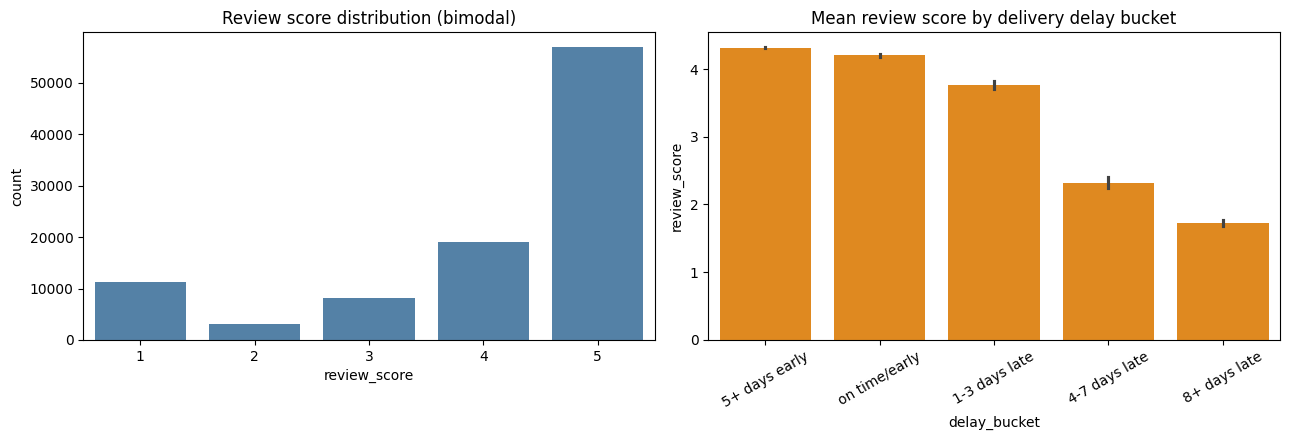

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.countplot(data=reviews_clean, x='review_score', order=[1,2,3,4,5], ax=axes[0], color='steelblue')
axes[0].set_title('Review score distribution (bimodal)')

bucket_order = ['5+ days early', 'on time/early', '1-3 days late', '4-7 days late', '8+ days late']
sns.barplot(data=merged, x='delay_bucket', y='review_score', order=bucket_order, ax=axes[1], color='darkorange')
axes[1].set_title('Mean review score by delivery delay bucket')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


## 10. Some questions to think about
- The review gap selection bias : worth quantifying its effect on any headline average satisfaction number, or does it need a deeper investigation first?

- The low repeat purchase rate (3.1%) : is this in scope for our project's core question, or a finding worth mentioning but not building a dedicated chart around?

- The delay vs review relationship is strong enough that it's likely the central chart for the final presentation, so need to confirm if this is the direction to build toward?


# 11. Deeper Analysis: Bringing A, B & C Together Against Review Score

The sections above establish the central delay vs review relationship using only Category D's own data. Now that Category A (payments/timing), Category B (categories), and Category C (seller logistics, distance, processing/transport split) all have richer outputs, this section tests review score against every one of those variables directly and this is where all the categories genuinely combine, not just sit side by side.

Also revisits two items explicitly deferred in the original Category D report: the review gap selection bias explanation (follow up B) and the repeat purchase vs delivery cross analysis (follow up C). Both are addressed properly below, not just re flagged as open.


## 11.1 Load Track A/B/C's enriched outputs

`order_logistics_master.csv` (Track C) is at order-seller grain, mostly but not always one row
per order -- deduplicated here by keeping the highest-value item per order where an order spans
multiple sellers, consistent with how Track B defines "primary" for multi-item orders.

In [29]:
order_logistics = pd.read_csv('order_logistics_master.csv')
order_products_summary = pd.read_csv('order_products_summary.csv')
category_lookup = pd.read_csv('category_lookup.csv')

# use the enhanced version
sellers_master = pd.read_csv('sellers_master_enhanced.csv')

order_logistics_dedup = (
    order_logistics.sort_values('order_item_value', ascending=False)
    .drop_duplicates('order_id')
)

print("order_logistics_master rows:", len(order_logistics), "-> deduplicated to:", len(order_logistics_dedup))

order_logistics_master rows: 100010 -> deduplicated to: 98666


## 11.2 Processing time vs. transport time vs. review score

The original Section 9 already shows total delay predicts review score. Category C's split lets us ask a more detailed question: does it matter where the delay comes from? Is it the seller's own handling
speed, or the shipping network?

In [30]:
review_logistics = order_logistics_dedup.merge(reviews_clean, on='order_id', how='inner')

review_logistics['processing_bin'] = pd.qcut(review_logistics['processing_days'].clip(lower=0), q=5, duplicates='drop')
review_logistics['transport_bin'] = pd.qcut(review_logistics['transport_days'].clip(lower=0), q=5, duplicates='drop')

print("Review score by processing-time quintile:")
print(review_logistics.groupby('processing_bin', observed=True)['review_score'].mean())

print("\nReview score by transport-time quintile:")
print(review_logistics.groupby('transport_bin', observed=True)['review_score'].mean())


Review score by processing-time quintile:
processing_bin
(-0.001, 1.005]     4.287579
(1.005, 1.825]      4.230023
(1.825, 2.927]      4.176425
(2.927, 4.681]      4.102760
(4.681, 125.776]    3.859273
Name: review_score, dtype: float64

Review score by transport-time quintile:
transport_bin
(-0.001, 3.267]      4.366691
(3.267, 6.071]       4.333142
(6.071, 8.262]       4.294860
(8.262, 13.451]      4.230565
(13.451, 205.191]    3.553011
Name: review_score, dtype: float64


**Finding:** both matter, but not equally.

- Across quintiles, transport time spans 4.37 -> 3.55 (a 0.82-point drop), while processing time spans 4.29 -> 3.86 (a smaller 0.43 point drop).

- The shipping part appears to hurt satisfaction more than the seller's own
handling speed which is a genuinely actionable distinction: interventions aimed at carrier/logistics speed may matter more to customer sentiment than pushing sellers to ship faster, though both can help.

## 11.3 Geography: same state, cross state, and distance

In [31]:
print("Review score: same state vs. cross state delivery")
print(review_logistics.groupby('same_state')['review_score'].mean().round(3))

review_logistics['distance_bin'] = pd.qcut(review_logistics['distance_km'].dropna(), q=5, duplicates='drop')
print("\nReview score by distance quintile:")
print(review_logistics.groupby('distance_bin', observed=True)['review_score'].mean())


Review score: same state vs. cross state delivery
same_state
False    4.046
True     4.209
Name: review_score, dtype: float64

Review score by distance quintile:
distance_bin
(-0.001, 115.64]      4.216207
(115.64, 347.92]      4.141486
(347.92, 529.557]     4.102232
(529.557, 876.687]    4.065586
(876.687, 3579.34]    3.996356
Name: review_score, dtype: float64


**Finding:** same state orders average 4.21 vs. 4.05 for cross state which is a real but modest gap (0.16 points). Distance shows the same modest, monotonic pattern (4.22 down to 4.00 across quintiles).

- Both are real, but both secondary in size to the transport time finding above  geography likely matters mostly through its effect on transport time, not as a fully separate factor.

## 11.4 Freight burden vs. review score : checked, and largely ruled out

Track B found freight to price ratio varies hugely by category (up to 54% for some). Worth checking directly whether that burden itself dents satisfaction, independent of delivery speed.

In [32]:
review_logistics['freight_ratio_clean'] = review_logistics['freight_ratio'].replace([float('inf')], None)
review_logistics['freight_bin'] = pd.qcut(review_logistics['freight_ratio_clean'].dropna(), q=5, duplicates='drop')

print(review_logistics.groupby('freight_bin', observed=True)['review_score'].mean())

freight_bin
(-0.001, 0.114]    4.126372
(0.114, 0.182]     4.122185
(0.182, 0.272]     4.126149
(0.272, 0.434]     4.082469
(0.434, 21.447]    4.065513
Name: review_score, dtype: float64


**Finding:** nearly flat (4.13 down to 4.07 across quintiles) which is a much weaker effect than delay, transport time, or even distance.

- Freight burden itself does not appear to meaningfully
hurt satisfaction which is worth stating clearly, since it's a real nuance on top of Category B's freight ratio finding: those high freight ratio categories may be a margin/cost concern, but not obviously a satisfaction risk on their own.

## 11.5 Category and payment type vs. review score

In [33]:
cat_reviews = order_products_summary.merge(reviews_clean, on='order_id', how='inner')
top15_categories = category_lookup.head(15)['product_category_name_english']

print("Review score by category (top 15 by volume):\n")
print(
    cat_reviews[cat_reviews['primary_category'].isin(top15_categories)]
    .groupby('primary_category')['review_score'].mean()
    .sort_values()
)


Review score by category (top 15 by volume):

primary_category
bed_bath_table           3.978211
telephony                4.010125
computers_accessories    4.027300
furniture_decor          4.028662
baby                     4.055101
watches_gifts            4.066906
auto                     4.096891
electronics              4.099762
housewares               4.150692
garden_tools             4.154002
sports_leisure           4.174266
cool_stuff               4.182073
health_beauty            4.183951
toys                     4.190774
perfumery                4.209384
Name: review_score, dtype: float64


In [35]:
pay_reviews = orders_master.merge(reviews_clean, on='order_id', how='inner')

print("Review score by payment type:\n")
print(pay_reviews.groupby('payment_type_primary')['review_score'].agg(['mean', 'count']))

Review score by payment type:

                          mean  count
payment_type_primary                 
boleto                4.086830  19636
credit_card           4.087995  74391
debit_card            4.168968   1521
not_defined           1.666667      3
voucher               4.004486   3121


**Finding:** category spread is modest (3.98 to 4.21) with `bed_bath_table`, as the single highest volume category, and has the lowest average score among top categories, worth a specific look given its scale.

- Payment type is close to flat, with voucher scoring slightly lower
(4.00) than card payments (4.09) which again is a modest but real data point for Category A's still open voucher cancellation question: voucher orders that do complete also tend to review a little worse, adding weak further support to the different customer profile theory over redemption
failure.


**Note:** `not_defined` payment type shows an average of 1.67, but from only 3 orders so its not meaningful, mentioned only so it isn't mistaken for a real pattern if seen in a raw table.

## 11.6 Review score over time and a direct link back to Track A's unexplained spike

In [37]:
pay_reviews['purchase_month'] = pay_reviews['purchase_month']
monthly_reviews = pay_reviews.groupby('purchase_month')['review_score'].mean()

print(monthly_reviews[(monthly_reviews.index >= '2017-01') & (monthly_reviews.index <= '2018-08')])

purchase_month
2017-01    4.062025
2017-02    4.016403
2017-03    4.074032
2017-04    4.045245
2017-05    4.139389
2017-06    4.146986
2017-07    4.173935
2017-08    4.238948
2017-09    4.187956
2017-10    4.123449
2017-11    3.910561
2017-12    4.017819
2018-01    4.041105
2018-02    3.825689
2018-03    3.752798
2018-04    4.162139
2018-05    4.194180
2018-06    4.277479
2018-07    4.263006
2018-08    4.256130
Name: review_score, dtype: float64


**Finding:** Review score by month shows a real dip in March 2018 (3.75), the lowest of any regular month which matches Category A's unexplained late rate spike (20.7% that month) almost exactly.

- Although this still doesn't explain why March 2018 had operational trouble, but it confirms the spike was real and genuinely felt
by customers, not a data artifact.

## 11.7 Revisiting the review gap selection bias (Track D's deferred follow up B)

The original report left two explanations undistinguished: genuine customer non response, or review requests censored by a fixed survey schedule that hadn't caught up yet for very recent orders. Checking that properly now.

In [38]:
reviews_raw = pd.read_csv('order_reviews_dataset.csv')
reviews_raw['review_creation_date'] = pd.to_datetime(reviews_raw['review_creation_date'])
orders_master['delivered_ts'] = pd.to_datetime(orders_master['delivered_ts'])

timing_check = reviews_raw.merge(orders_master[['order_id', 'delivered_ts']], on='order_id', how='left')
timing_check['offset_from_delivery'] = (
    timing_check['review_creation_date'] - timing_check['delivered_ts']
).dt.total_seconds() / 86400

print("Review request timing, relative to actual delivery date:")
print(timing_check[timing_check['delivered_ts'].notna()]['offset_from_delivery'].describe())

Review request timing, relative to actual delivery date:
count    96359.000000
mean        -0.239336
std          4.676419
min       -186.975081
25%          0.119479
50%          0.237095
75%          0.375689
max        106.375486
Name: offset_from_delivery, dtype: float64


**Finding, step 1:** review requests are tightly clustered right after delivery with median of 0.24 days (about 5 to 6 hours), interquartile range just 0.12 to 0.38 days.

- This strongly suggests review requests fire on a near fixed, and a near immediate schedule tied to actual delivery, not a schedule tied to the original estimate.

In [40]:
max_delivered = orders_master['delivered_ts'].max()
delivered = orders_master[orders_master['is_delivered']]
no_review = delivered[~delivered['order_id'].isin(reviews_clean['order_id'])]
has_review = delivered[delivered['order_id'].isin(reviews_clean['order_id'])]

print("If missing reviews were a timing/censoring effect, no review orders should cluster near")
print("the dataset's extraction cutoff (i.e., not enough time yet).\n")

print("No review orders : days between their delivery and the dataset's max delivered_ts:")
print((max_delivered - no_review['delivered_ts']).dt.total_seconds().div(86400).describe())

print("\nReviewed orders : same measure, for comparison:")
print((max_delivered - has_review['delivered_ts']).dt.total_seconds().div(86400).describe())

If missing reviews were a timing/censoring effect, no review orders should cluster near
the dataset's extraction cutoff (i.e., not enough time yet).

No review orders : days between their delivery and the dataset's max delivered_ts:
count    646.000000
mean     292.211057
std      146.492990
min       42.719306
25%      181.637867
50%      277.263218
75%      398.388235
max      720.156181
Name: delivered_ts, dtype: float64

Reviewed orders : same measure, for comparison:
count    95824.000000
mean       275.919522
std        152.237729
min          0.000000
25%        154.075003
50%        256.692425
75%        386.118313
max        735.983495
Name: delivered_ts, dtype: float64


**Finding, step 2:** if timing explained the gap, no review orders should skew toward recent deliveries (few days before the cutoff). But they don't as median is 277 days before the cutoff, which is essentially the same as (or in fact slightly larger than) reviewed orders' median of 257 days.

- Combined with the near immediate review request timing above, this rules out not enough time yet as the explanation.

**Conclusion:** the missing reviews genuinely look like non response, not a data collection artifact.

- This strengthens (rather than just leaves open) the original finding that the missing reviews are concentrated where satisfaction was probably worst and so worth stating this more confidently now.

## 11.8 Repeat purchase vs. first order delivery experience (Category D's deferred follow up C)

Does a customer's first delivery experience relate to whether they come back? Using each customer's first order specifically, rather than an average across all their orders, since the first order is what a repeat purchase decision would actually be based on.

In [42]:
cust_orders = orders_master.merge(customers_master[['customer_id', 'customer_unique_id']], on='customer_id', how='left')
repeat_counts = customers_master.groupby('customer_unique_id')['customer_order_count'].first().reset_index()

first_orders = (
    cust_orders.sort_values('purchase_ts')
    .drop_duplicates('customer_unique_id', keep='first')
    .merge(repeat_counts, on='customer_unique_id')
)
first_orders['is_repeat_customer'] = first_orders['customer_order_count'] > 1

print("First order delivery delay, one time vs. eventual repeat customers:")
print(first_orders.groupby('is_repeat_customer')['delivery_delay_days'].mean().round(2))

print("\nFirst order late rate, one time vs. eventual repeat customers:")
print(first_orders.groupby('is_repeat_customer')['is_late'].mean().round(4))


First order delivery delay, one time vs. eventual repeat customers:
is_repeat_customer
False   -11.13
True    -12.07
Name: delivery_delay_days, dtype: float64

First order late rate, one time vs. eventual repeat customers:
is_repeat_customer
False    0.0795
True     0.0641
Name: is_late, dtype: float64


**Finding:** customers who went on to become repeat buyers had a modestly better first delivery experience with 6.4% late vs. 7.9% for one time customers, and a slightly better average delay (−12.07 vs. −11.13 days).

- The effect is real but not huge so worth presenting as supporting evidence for better delivery means more repeat business, not as a dominant driver of
repeat purchase on its own (3.1% repeat rate is low overall, so plenty of other factors are clearly at play too).

## 11.9 Does seller reliability show up in the reviews they receive?

A direct link between Category C's seller level performance metrics and actual customer sentiment  not just delivery speed, but the reviews that speed produces.

In [43]:
order_seller_map = order_logistics_dedup[['order_id', 'seller_id']]
seller_reviews = order_seller_map.merge(reviews_clean, on='order_id', how='inner').merge(
    sellers_master[['seller_id', 'pct_late', 'low_confidence']], on='seller_id', how='left'
)

seller_level = (
    seller_reviews[seller_reviews['low_confidence'] == False]
    .groupby('seller_id')
    .agg(avg_review=('review_score', 'mean'), pct_late=('pct_late', 'first'))
    .dropna()
)

print("Correlation, seller late-rate vs. seller average review score:", round(seller_level['pct_late'].corr(seller_level['avg_review']), 3))


Correlation, seller late-rate vs. seller average review score: -0.396


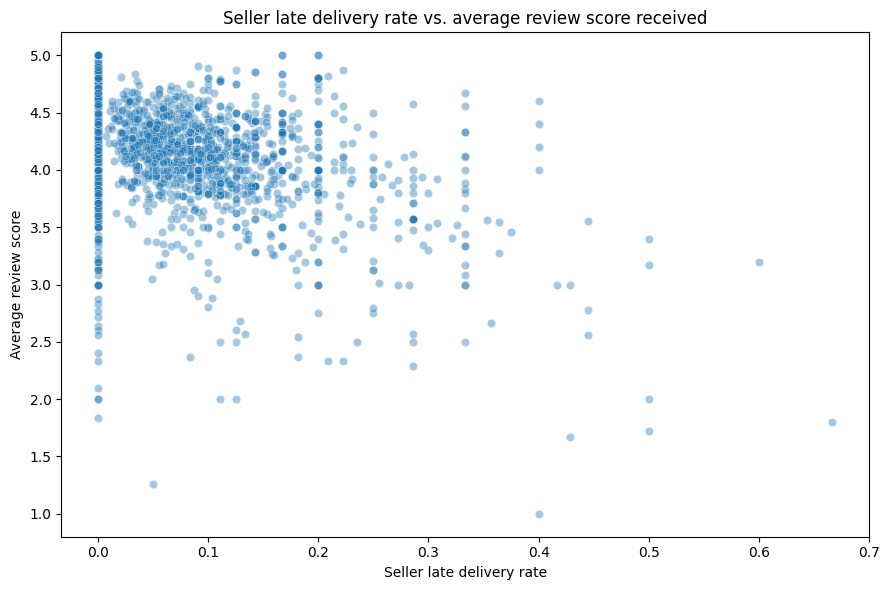

In [45]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(data=seller_level, x='pct_late', y='avg_review', alpha=0.4, ax=ax)
ax.set_title('Seller late delivery rate vs. average review score received')
ax.set_xlabel('Seller late delivery rate')
ax.set_ylabel('Average review score')
plt.tight_layout()
plt.show()

**Finding:** a real, moderate negative correlation (−0.395). This confirms the order level delay review relationship holds at the seller level too, and gives Category E a ready made, review grounded way to rank sellers for the dashboard (not just by delay, but by the satisfaction outcome that delay actually produces).

In [46]:
seller_full = seller_level.reset_index().drop(columns=['pct_late']).merge(
    sellers_master[sellers_master['low_confidence'] == False],
    on='seller_id', how='inner'
)

seller_vars = ['pct_late', 'avg_transport_days', 'avg_processing_days', 'freight_ratio', 'pct_early', 'n_orders']
seller_corrs = seller_full[seller_vars + ['avg_review']].corr()['avg_review'].drop('avg_review')
seller_corrs.reindex(seller_corrs.abs().sort_values(ascending=False).index)

,avg_review
pct_early,0.604278
avg_processing_days,-0.448517
pct_late,-0.396249
avg_transport_days,-0.296245
n_orders,-0.021961
freight_ratio,0.015561


**Finding:** at the *seller* level, `avg_processing_days` (−0.449) is a stronger correlate of average review score than `avg_transport_days` (−0.296) which is the reverse of the order level finding, where transport
time won out.

- This makes sense once you consider what varies at each level: transport time is heavily influenced by factors outside any seller's control like (distance, carrier performance), so it's a strong predictor of any  individual order's outcome, but doesn't cleanly separate good sellers from bad ones on average.

- A seller's typical processing speed is more consistently within their own control, so it's a better signal of which sellers are reliably good.

## 11.10 Which single variable predicts review score best?

A closing summary, ranking every tested variable by correlation strength -- useful as a quick
reference for prioritizing the final report and dashboard, rather than treating every finding
above as equally important.

In [ ]:
driver_vars = [
    'delivery_delay_days', 'processing_days', 'transport_days',
    'distance_km', 'freight_ratio', 'order_item_value', 'freight_value', 'n_items'
]
driver_corrs = review_logistics[driver_vars + ['review_score']].corr()['review_score'].drop('review_score')
driver_ranking = driver_corrs.reindex(driver_corrs.abs().sort_values(ascending=False).index)
driver_ranking


,review_score
transport_days,-0.299413
delivery_delay_days,-0.266740
processing_days,-0.155323
n_items,-0.092028
freight_value,-0.077691
distance_km,-0.057508
order_item_value,-0.034833
freight_ratio,-0.019716


**Finding:** `transport_days` is actually the single strongest linear correlation with review score (−0.299), edging out `delivery_delay_days` itself (−0.267) which is a small but interesting nuance: the raw time a customer waits may matter just as much as whether that wait beat the (heavily padded) promised estimate. `processing_days` is meaningfully weaker (−0.155), consistent with 11.2's finding that transport delays hurt more than seller side delays.

- `freight_ratio`, `distance_km`, and order value are all weak (under 0.06)so confirmed, not just suggested, as secondary factors.

## 11.11 Does having a comment, or response speed, relate to score?

Flagged as a candidate question earlier but not yet actually tested so worth checking directly: do customers who leave a written comment (not just a star rating) tend to feel more strongly, and does how quickly someone responds to the review request say anything about their sentiment?

In [47]:
print("Review score: orders with a comment vs. without")
print(reviews_clean.groupby('has_comment')['review_score'].agg(['mean', 'count']))

Review score: orders with a comment vs. without
                 mean  count
has_comment                 
False        4.376204  56177
True         3.702984  42496


**Finding:** orders without a comment average 4.38 and orders
with a comment average 3.70. A 0.68 point gap, which is bigger than most of the delay related effects found elsewhere in this notebook.

- Makes intuitive sense: leaving a written comment (versus just a star rating) more often signals a customer motivated enough to explain themselves, which skews toward complaints.

- Practical implication: `has_comment` is a cheap, strong proxy for
dissatisfaction, even without reading the (mostly Portuguese, largely unprocessed) comment text itself so worth considering as a dashboard filter or flag on its own.

In [50]:
reviews_clean = reviews_clean.copy()
reviews_clean.loc[:,'response_bin'] = pd.qcut(reviews_clean['days_to_review_response'].clip(lower=0), q=5, duplicates='drop')
print("Review score by response speed quintile:")
print(reviews_clean.groupby('response_bin', observed=True)['review_score'].mean())

print("\nOverall correlation, days_to_review_response vs review_score:", round(reviews_clean['days_to_review_response'].corr(reviews_clean['review_score']), 3))


Review score by response speed quintile:
response_bin
(0.0882, 0.951]     3.791741
(0.951, 1.462]      4.277592
(1.462, 2.517]      4.112643
(2.517, 3.527]      4.179630
(3.527, 518.699]    4.069727
Name: review_score, dtype: float64

Overall correlation, days_to_review_response vs review_score: 0.007


**Finding:** essentially no overall relationship (correlation 0.007) so response speed doesn't meaningfully predict score.

- Although one mild pattern worth a passing mention, not a headline which is that the fastest responding quintile (under 1 day) scores slightly lower (3.79) than the rest (4.07 to 4.28), possibly reflecting customers eager to vent immediately but the effect is weak and not monotonic across the remaining bins, so this reads as noise more than a real pattern. And hence ruled out as a useful predictor overall.

## 11.11 Some more questions to think about

- The review gap selection bias (deferred follow up B) is now resolved, not just documented as a limitation.

- The repeat purchase vs delivery link (deferred follow up C) is now built and confirmed with modest but real and ready to cite directly in the final presentation's why delivery matters for growth argument.

- `bed_bath_table`'s below average review score, despite being the single largest category by volume is worth a specific look; if a large share of orders come from a category with below average satisfaction, that's a meaningful blended average risk for the marketplace overall.

- The transport vs processing time distinction (11.2) and the transport time edges out delay finding (11.10) both point toward the same practical recommendation.
